In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import everything as text first
df = pd.read_csv(
    "/content/Finaldata.csv",
    dtype=str,
    low_memory=False
)

# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"\s+", "_", regex=True)
)

# Columns that should be numeric
numeric_columns = [
    "total_population",
    "poverty_pct",
    "median_household_income",
    "total_households",
    "no_vehicle_households",
    "pct_no_vehicles",
    "food_insecurity_pct",
    "physical_inactivity_pct",
    "food_environment_index",
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

# Remove formatting characters and convert to numbers
for column in numeric_columns:
    if column in df.columns:
        df[column] = (
            df[column]
              .str.strip()
              .str.replace("$", "", regex=False)
              .str.replace(",", "", regex=False)
              .str.replace("%", "", regex=False)
              .replace({
                  "": np.nan,
                  "NA": np.nan,
                  "N/A": np.nan,
                  "null": np.nan
              })
        )

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

# Preserve five-digit county FIPS codes
df["county_fips"] = (
    df["county_fips"]
      .str.strip()
      .str.replace(r"\.0$", "", regex=True)
      .str.zfill(5)
)

df.head()

,county_fips,county_name,total_population,poverty_pct,median_household_income,total_households,no_vehicle_households,pct_no_vehicles,food_insecurity_pct,physical_inactivity_pct,food_environment_index,obesity_age_adjusted_pct,diabetes_age_adjusted_pct,chd_age_adjusted_pct,barrier_profile_excel
0,01001,"Autauga County, Alabama",59947.0,11.3,72481.0,22917.0,947.0,4.1,15.1,26.0,7.1,39.5,11.4,5.6,Mobility barrier
1,01003,"Baldwin County, Alabama",246989.0,10.1,78775.0,98574.0,2644.0,2.7,14.8,23.7,7.7,35.0,10.4,5.5,Mobility barrier
2,01005,"Barbour County, Alabama",24643.0,21.4,46042.0,9128.0,958.0,10.5,19.7,34.5,6.4,47.1,16.5,7.4,Compounded barrier
3,01007,"Bibb County, Alabama",22130.0,22.5,52541.0,7704.0,418.0,5.4,19.3,31.9,7.5,43.7,13.9,7.0,Compounded barrier
4,01009,"Blount County, Alabama",59518.0,12.9,64190.0,22180.0,897.0,4.0,17.3,27.7,7.7,36.0,11.3,6.3,Mobility barrier


In [12]:
df[
    [
        "county_fips",
        "county_name",
        "median_household_income",
        "pct_no_vehicles"
    ]
].head()

,county_fips,county_name,median_household_income,pct_no_vehicles
0,01001,"Autauga County, Alabama",72481.0,4.1
1,01003,"Baldwin County, Alabama",78775.0,2.7
2,01005,"Barbour County, Alabama",46042.0,10.5
3,01007,"Bibb County, Alabama",52541.0,5.4
4,01009,"Blount County, Alabama",64190.0,4.0


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Confirm that the required columns exist
required_columns = [
    "county_name",
    "total_population",
    "poverty_pct",
    "pct_no_vehicles",
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"These required columns are missing: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

# Ensure required variables are numeric
numeric_columns = [
    "total_population",
    "poverty_pct",
    "pct_no_vehicles",
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Convert no-vehicle values to percentage points only if needed
# Example: 0.041 becomes 4.1
vehicle_values = df["pct_no_vehicles"].dropna()

if not vehicle_values.empty and vehicle_values.max() <= 1:
    df["pct_no_vehicles"] = df["pct_no_vehicles"] * 100

# Calculate national county-level 75th percentile cutoffs
poverty_cutoff = df["poverty_pct"].dropna().quantile(0.75)
vehicle_cutoff = df["pct_no_vehicles"].dropna().quantile(0.75)

print(f"Poverty cutoff: {poverty_cutoff:.1f}%")
print(f"No-vehicle cutoff: {vehicle_cutoff:.1f}%")

# Create the barrier groups
valid_rows = df[
    ["poverty_pct", "pct_no_vehicles"]
].notna().all(axis=1)

poverty = df.loc[valid_rows, "poverty_pct"]
vehicle = df.loc[valid_rows, "pct_no_vehicles"]

profiles = np.select(
    [
        (poverty >= poverty_cutoff) &
        (vehicle >= vehicle_cutoff),

        (poverty >= poverty_cutoff) &
        (vehicle < vehicle_cutoff),

        (poverty < poverty_cutoff) &
        (vehicle >= vehicle_cutoff)
    ],
    [
        "Compounded barrier",
        "Affordability barrier",
        "Mobility barrier"
    ],
    default="Lower measured barriers"
)

df["barrier_profile"] = pd.NA
df.loc[valid_rows, "barrier_profile"] = profiles

# Check the results
print()
print(df["barrier_profile"].value_counts(dropna=False))

Poverty cutoff: 17.3%
No-vehicle cutoff: 7.1%

barrier_profile
<NA>                       1045431
Lower measured barriers       1948
Compounded barrier             404
Affordability barrier          400
Mobility barrier               392
Name: count, dtype: int64


High-poverty cutoff: 17.3%
High no-vehicle cutoff: 7.1%

County counts by barrier group:
barrier_profile
<NA>                       1045431
Lower measured barriers       1948
Compounded barrier             404
Affordability barrier          400
Mobility barrier               392
Name: count, dtype: int64

Counties displayed: 3,144


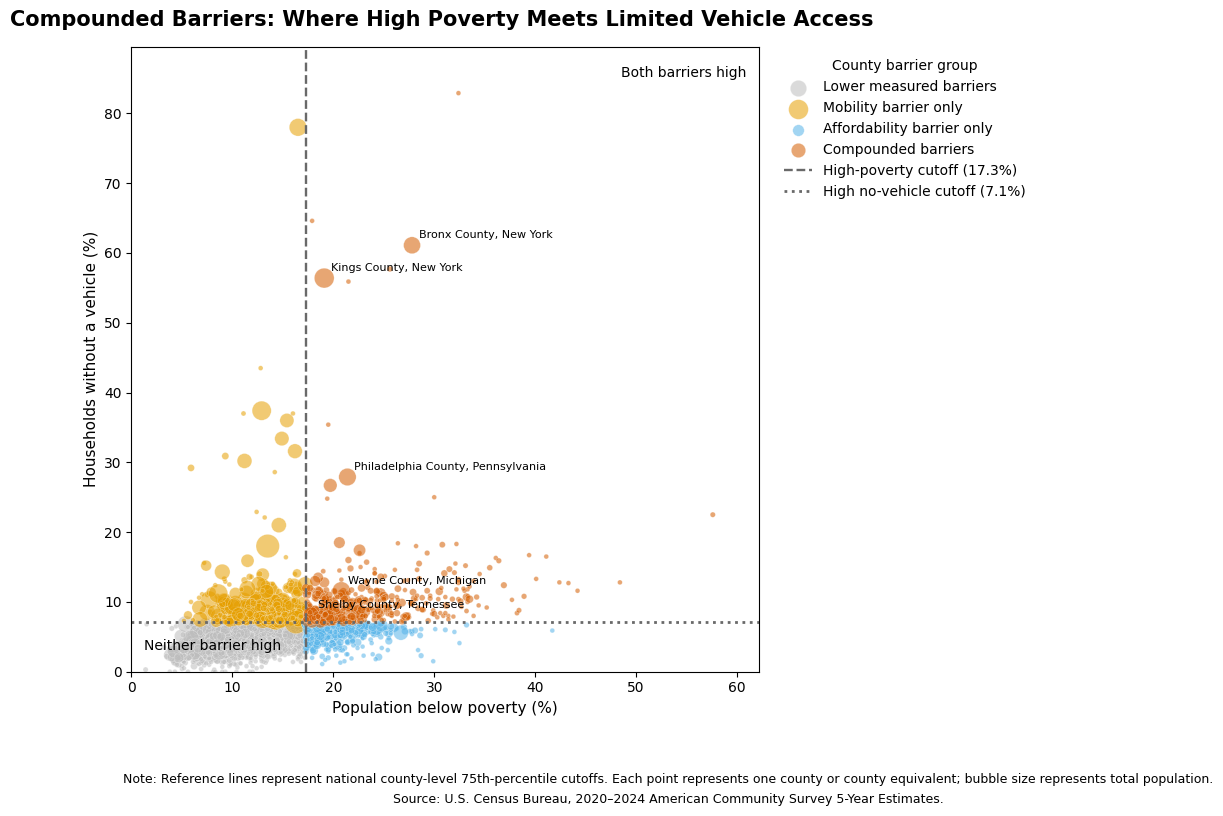

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Confirm and prepare required columns
# ---------------------------------------------------------

# Handle either possible spelling of the vehicle column
if (
    "pct_no_vehicles" not in df.columns
    and "pct_no_vehicle" in df.columns
):
    df = df.rename(
        columns={"pct_no_vehicle": "pct_no_vehicles"}
    )

required_columns = [
    "county_name",
    "total_population",
    "poverty_pct",
    "pct_no_vehicles"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

# Convert required columns to numeric
numeric_columns = [
    "total_population",
    "poverty_pct",
    "pct_no_vehicles"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Convert no-vehicle values from decimals to percentage points if needed
vehicle_values = df["pct_no_vehicles"].dropna()

if not vehicle_values.empty and vehicle_values.max() <= 1:
    df["pct_no_vehicles"] = (
        df["pct_no_vehicles"] * 100
    )

# ---------------------------------------------------------
# 2. Calculate national county-level cutoffs
# ---------------------------------------------------------

poverty_cutoff = (
    df["poverty_pct"]
    .dropna()
    .quantile(0.75)
)

vehicle_cutoff = (
    df["pct_no_vehicles"]
    .dropna()
    .quantile(0.75)
)

print(f"High-poverty cutoff: {poverty_cutoff:.1f}%")
print(f"High no-vehicle cutoff: {vehicle_cutoff:.1f}%")

# ---------------------------------------------------------
# 3. Create county barrier groups
# ---------------------------------------------------------

valid_profile_rows = df[
    ["poverty_pct", "pct_no_vehicles"]
].notna().all(axis=1)

poverty = df.loc[
    valid_profile_rows,
    "poverty_pct"
]

vehicle = df.loc[
    valid_profile_rows,
    "pct_no_vehicles"
]

conditions = [
    (
        (poverty >= poverty_cutoff)
        & (vehicle >= vehicle_cutoff)
    ),
    (
        (poverty < poverty_cutoff)
        & (vehicle >= vehicle_cutoff)
    ),
    (
        (poverty >= poverty_cutoff)
        & (vehicle < vehicle_cutoff)
    )
]

categories = [
    "Compounded barrier",
    "Mobility barrier",
    "Affordability barrier"
]

df["barrier_profile"] = pd.NA

df.loc[
    valid_profile_rows,
    "barrier_profile"
] = np.select(
    conditions,
    categories,
    default="Lower measured barriers"
)

print("\nCounty counts by barrier group:")
print(df["barrier_profile"].value_counts(dropna=False))

# ---------------------------------------------------------
# 4. Set plotting order, labels, and colors
# ---------------------------------------------------------

# These values match the categories stored in the dataframe
profile_order = [
    "Lower measured barriers",
    "Mobility barrier",
    "Affordability barrier",
    "Compounded barrier"
]

# These labels appear in the legend
display_labels = {
    "Lower measured barriers":
        "Lower measured barriers",

    "Mobility barrier":
        "Mobility barrier only",

    "Affordability barrier":
        "Affordability barrier only",

    "Compounded barrier":
        "Compounded barriers"
}

# Colorblind-friendly palette
color_map = {
    "Lower measured barriers": "#BDBDBD",
    "Mobility barrier": "#E69F00",
    "Affordability barrier": "#56B4E9",
    "Compounded barrier": "#D55E00"
}

# ---------------------------------------------------------
# 5. Prepare bubble-chart data
# ---------------------------------------------------------

bubble_df = df.dropna(
    subset=[
        "county_name",
        "poverty_pct",
        "pct_no_vehicles",
        "total_population",
        "barrier_profile"
    ]
).copy()

# Remove impossible values
bubble_df = bubble_df[
    (bubble_df["total_population"] > 0)
    & (bubble_df["poverty_pct"] >= 0)
    & (bubble_df["pct_no_vehicles"] >= 0)
].copy()

# Convert population into bubble sizes
bubble_df["bubble_size"] = np.clip(
    np.sqrt(
        bubble_df["total_population"]
    ) / 8,
    12,
    450
)

print(
    f"\nCounties displayed: {len(bubble_df):,}"
)

# ---------------------------------------------------------
# 6. Create the visualization
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 8)
)

for profile in profile_order:

    group = bubble_df[
        bubble_df["barrier_profile"] == profile
    ]

    ax.scatter(
        group["poverty_pct"],
        group["pct_no_vehicles"],
        s=group["bubble_size"],
        color=color_map[profile],
        alpha=0.55,
        edgecolors="white",
        linewidth=0.3,
        label=display_labels[profile]
    )

# Add 75th-percentile cutoff lines
ax.axvline(
    poverty_cutoff,
    linestyle="--",
    linewidth=1.7,
    color="dimgray",
    label=(
        f"High-poverty cutoff "
        f"({poverty_cutoff:.1f}%)"
    )
)

ax.axhline(
    vehicle_cutoff,
    linestyle=":",
    linewidth=2,
    color="dimgray",
    label=(
        f"High no-vehicle cutoff "
        f"({vehicle_cutoff:.1f}%)"
    )
)

# ---------------------------------------------------------
# 7. Label populous compounded-barrier counties
# ---------------------------------------------------------

label_counties = (
    bubble_df[
        bubble_df["barrier_profile"]
        == "Compounded barrier"
    ]
    .nlargest(
        5,
        "total_population"
    )
)

for _, row in label_counties.iterrows():

    ax.annotate(
        row["county_name"],
        (
            row["poverty_pct"],
            row["pct_no_vehicles"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

# ---------------------------------------------------------
# 8. Titles, axes, and quadrant labels
# ---------------------------------------------------------

ax.set_title(
    "Compounded Barriers: Where High Poverty Meets Limited Vehicle Access ",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Population below poverty (%)",
    fontsize=11
)

ax.set_ylabel(
    "Households without a vehicle (%)",
    fontsize=11
)

#Include all counties and outliers
x_max = bubble_df["poverty_pct"].max()
y_max = bubble_df["pct_no_vehicles"].max()
ax.set_xlim(
    0,
    x_max * 1.08
)
ax.set_ylim(
    0,
    y_max * 1.08
)

#without outliers for readability
#x_max = bubble_df["poverty_pct"].max()
#y_max = bubble_df["pct_no_vehicles"].max()

#ax.set_xlim(0, x_max * 1.08)
#ax.set_ylim(0, y_max * 1.08)

# Zoom in for readability
#ax.set_xlim(0, 40)
#ax.set_ylim(0, 30)

ax.text(
    0.98,
    0.97,
    "Both barriers high",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10
)

ax.text(
    0.02,
    0.03,
    "Neither barrier high",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10
)

# ---------------------------------------------------------
# 9. Legend and source note
# ---------------------------------------------------------

ax.legend(
    title="County barrier group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

fig.text(
    0.5,
    0.015,
    "Note: Reference lines represent national county-level 75th-percentile cutoffs. "
    "Each point represents one county or county equivalent; bubble size represents "
    "total population.",
    ha="center",
    fontsize=9,
    wrap=True
)

fig.text(
    0.5,
    -0.01,
    "Source: U.S. Census Bureau, 2020–2024 American Community "
    "Survey 5-Year Estimates.",
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.08, 0.82, 1]
)

# ---------------------------------------------------------
# 10. Save and display
# ---------------------------------------------------------

plt.savefig(
    "/content/poverty_transportation_barriers_full_range.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Handle either spelling of the vehicle column
if "pct_no_vehicles" not in df.columns and "pct_no_vehicle" in df.columns:
    df = df.rename(columns={"pct_no_vehicle": "pct_no_vehicles"})

# Columns needed
outcome_columns = [
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

numeric_columns = [
    "poverty_pct",
    "pct_no_vehicles",
    *outcome_columns
]

# Ensure values are numeric
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Treat zero disease estimates as missing
for column in outcome_columns:
    df.loc[df[column] <= 0, column] = np.nan

# Recreate barrier profile if it is missing
if "barrier_profile" not in df.columns:

    poverty_cutoff = df["poverty_pct"].quantile(0.75)
    vehicle_cutoff = df["pct_no_vehicles"].quantile(0.75)

    valid_rows = df[
        ["poverty_pct", "pct_no_vehicles"]
    ].notna().all(axis=1)

    poverty = df.loc[valid_rows, "poverty_pct"]
    vehicle = df.loc[valid_rows, "pct_no_vehicles"]

    df["barrier_profile"] = pd.NA

    df.loc[valid_rows, "barrier_profile"] = np.select(
        [
            (poverty >= poverty_cutoff) &
            (vehicle >= vehicle_cutoff),

            (poverty < poverty_cutoff) &
            (vehicle >= vehicle_cutoff),

            (poverty >= poverty_cutoff) &
            (vehicle < vehicle_cutoff)
        ],
        [
            "Compounded barrier",
            "Mobility barrier",
            "Affordability barrier"
        ],
        default="Lower measured barriers"
    )

print(df["barrier_profile"].value_counts(dropna=False))

barrier_profile
<NA>                       1045431
Lower measured barriers       1948
Compounded barrier             404
Affordability barrier          400
Mobility barrier               392
Name: count, dtype: int64


                         Obesity  Diabetes  CHD
barrier_profile                                
Lower measured barriers     36.5      10.2  5.6
Mobility barrier            36.5      10.7  5.8
Affordability barrier       39.7      13.1  6.7
Compounded barrier          42.2      14.5  7.0


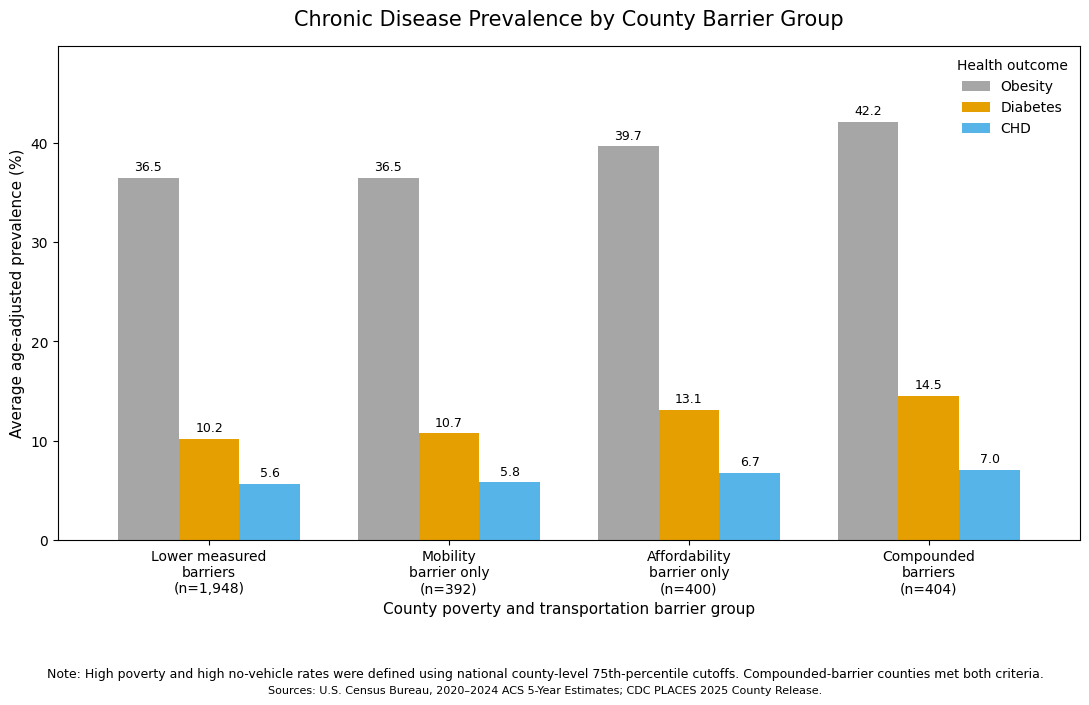

In [23]:
# Order shown on the chart
profile_order = [
    "Lower measured barriers",
    "Mobility barrier",
    "Affordability barrier",
    "Compounded barrier"
]

# Audience-friendly labels
profile_labels = [
    "Lower measured\nbarriers\n(n=1,948)",
    "Mobility\nbarrier only\n(n=392)",
    "Affordability\nbarrier only\n(n=400)",
    "Compounded\nbarriers\n(n=404)"
]

# Calculate average disease prevalence
barrier_summary = (
    df.dropna(subset=["barrier_profile"])
      .groupby("barrier_profile")[outcome_columns]
      .mean()
      .reindex(profile_order)
      .rename(columns={
          "obesity_age_adjusted_pct": "Obesity",
          "diabetes_age_adjusted_pct": "Diabetes",
          "chd_age_adjusted_pct": "CHD"
      })
)

print(barrier_summary.round(1))

# Colors remain consistent across charts
outcome_colors = [
    "#A6A6A6",  # obesity: gray
    "#E69F00",  # diabetes: orange
    "#56B4E9"   # CHD: blue
]

fig, ax = plt.subplots(figsize=(11, 7))

barrier_summary.plot(
    kind="bar",
    ax=ax,
    width=0.76,
    color=outcome_colors
)

ax.set_title(
    "Chronic Disease Prevalence by County Barrier Group",
    fontsize=15,
    pad=15
)

ax.set_xlabel(
    "County poverty and transportation barrier group",
    fontsize=11
)

ax.set_ylabel(
    "Average age-adjusted prevalence (%)",
    fontsize=11
)

ax.set_xticklabels(
    profile_labels,
    rotation=0
)

ax.set_ylim(
    0,
    barrier_summary.max().max() * 1.18
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=9
    )

ax.legend(
    title="Health outcome",
    frameon=False
)

fig.text(
    0.5,
    0.025,
    "Note: High poverty and high no-vehicle rates were defined using national "
    "county-level 75th-percentile cutoffs. Compounded-barrier counties met both criteria.",
    ha="center",
    fontsize=9,
    wrap=True
)

fig.text(
    0.5,
    0.002,
    "Sources: U.S. Census Bureau, 2020–2024 ACS 5-Year Estimates; "
    "CDC PLACES 2025 County Release.",
    ha="center",
    fontsize=8
)

plt.tight_layout(rect=[0, 0.09, 1, 1])

plt.savefig(
    "/content/chronic_disease_by_barrier_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
lower = barrier_summary.loc["Lower measured barriers"]
compounded = barrier_summary.loc["Compounded barrier"]

differences = compounded - lower

print(
    f"Obesity difference: {differences['Obesity']:.1f} percentage points"
)

print(
    f"Diabetes difference: {differences['Diabetes']:.1f} percentage points"
)

print(
    f"CHD difference: {differences['CHD']:.1f} percentage points"
)

Obesity difference: 5.6 percentage points
Diabetes difference: 4.3 percentage points
CHD difference: 1.4 percentage points


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Exact results from the SQL NTILE(4) analysis
comparison = pd.DataFrame({
    "Outcome": [
        "Obesity",
        "Diabetes",
        "Coronary heart disease"
    ],
    "Lowest quartile": [
        34.9,
        9.2,
        5.2
    ],
    "Highest quartile": [
        41.1,
        13.7,
        6.9
    ]
})

# Calculate absolute and relative differences
comparison["Percentage-point gap"] = (
    comparison["Highest quartile"] -
    comparison["Lowest quartile"]
)

comparison["Relative increase"] = (
    comparison["Percentage-point gap"] /
    comparison["Lowest quartile"] *
    100
)

# Rank outcomes from largest to smallest relative disparity
comparison = (
    comparison
    .sort_values("Relative increase", ascending=False)
    .reset_index(drop=True)
)

print(comparison.round(1))

                  Outcome  Lowest quartile  Highest quartile  \
0                Diabetes              9.2              13.7   
1  Coronary heart disease              5.2               6.9   
2                 Obesity             34.9              41.1   

   Percentage-point gap  Relative increase  
0                   4.5               48.9  
1                   1.7               32.7  
2                   6.2               17.8  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exact results from the SQL NTILE(4) analysis
prevalence = pd.DataFrame(
    {
        "Lowest": [34.9, 9.2, 5.2],
        "Lower-middle": [36.5, 10.3, 5.7],
        "Upper-middle": [38.3, 11.5, 6.2],
        "Highest": [41.1, 13.7, 6.9]
    },
    index=[
        "Obesity",
        "Diabetes",
        "Coronary heart disease"
    ]
)

# Calculate relative increase compared with the lowest quartile
relative_increase = (
    prevalence
    .div(prevalence["Lowest"], axis=0)
    .sub(1)
    .mul(100)
)

print("Actual prevalence:")
display(prevalence)

print("\nRelative increase from lowest quartile:")
display(relative_increase.round(1))

Actual prevalence:


,Lowest,Lower-middle,Upper-middle,Highest
Obesity,34.9,36.5,38.3,41.1
Diabetes,9.2,10.3,11.5,13.7
Coronary heart disease,5.2,5.7,6.2,6.9



Relative increase from lowest quartile:


,Lowest,Lower-middle,Upper-middle,Highest
Obesity,0.0,4.6,9.7,17.8
Diabetes,0.0,12.0,25.0,48.9
Coronary heart disease,0.0,9.6,19.2,32.7


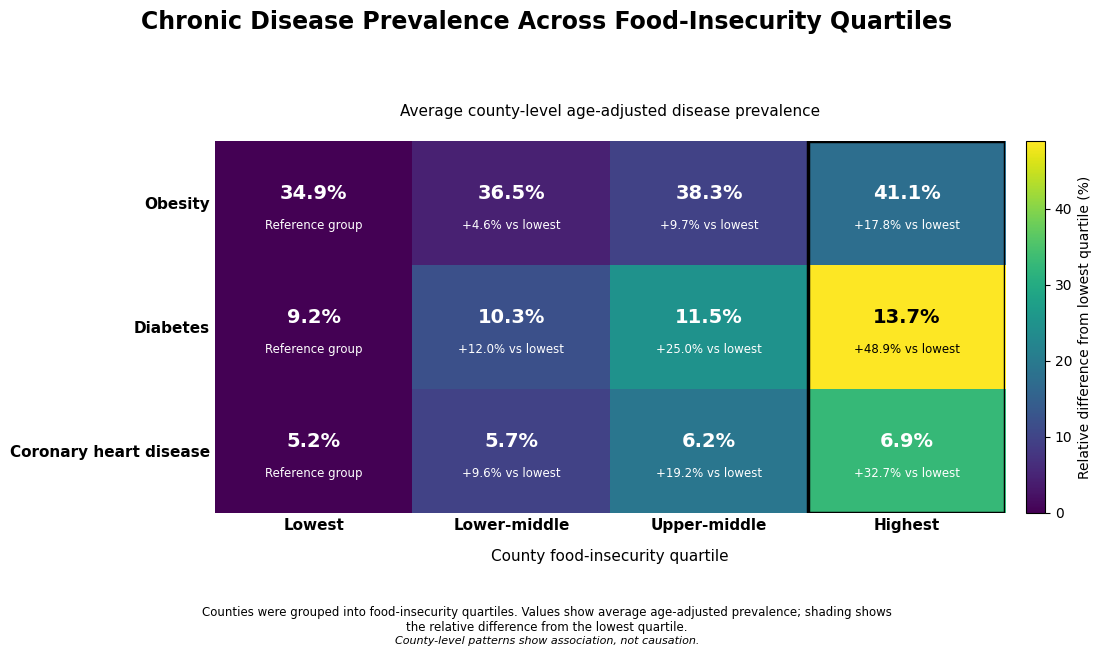

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

# --------------------------------------------------
# 1. Enter the quartile results
# --------------------------------------------------

prevalence = pd.DataFrame(
    {
        "Lowest": [34.9, 9.2, 5.2],
        "Lower-middle": [36.5, 10.3, 5.7],
        "Upper-middle": [38.3, 11.5, 6.2],
        "Highest": [41.1, 13.7, 6.9]
    },
    index=[
        "Obesity",
        "Diabetes",
        "Coronary heart disease"
    ]
)

# --------------------------------------------------
# 2. Calculate relative difference from lowest quartile
# --------------------------------------------------

relative_difference = (
    prevalence
    .div(prevalence["Lowest"], axis=0)
    .sub(1)
    .mul(100)
)

# --------------------------------------------------
# 3. Create heatmap
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6.7))

heatmap = ax.imshow(
    relative_difference.values,
    aspect="auto"
)

# --------------------------------------------------
# 4. Format axis labels
# --------------------------------------------------

ax.set_xticks(np.arange(len(prevalence.columns)))
ax.set_xticklabels(
    prevalence.columns,
    fontsize=11,
    fontweight="bold"
)

ax.set_yticks(np.arange(len(prevalence.index)))
ax.set_yticklabels(
    prevalence.index,
    fontsize=11,
    fontweight="bold"
)

ax.set_xlabel(
    "County food-insecurity quartile",
    fontsize=11,
    labelpad=12
)

ax.tick_params(
    axis="both",
    length=0
)

# --------------------------------------------------
# 5. Add values inside each cell
# --------------------------------------------------

maximum_difference = relative_difference.to_numpy().max()

for row in range(prevalence.shape[0]):
    for column in range(prevalence.shape[1]):

        prevalence_value = prevalence.iloc[row, column]
        difference_value = relative_difference.iloc[row, column]

        if column == 0:
            comparison_label = "Reference group"
        else:
            comparison_label = f"+{difference_value:.1f}% vs lowest"

        # Choose a readable text color
        normalized_value = difference_value / maximum_difference

        if normalized_value < 0.32:
            text_color = "white"
        elif normalized_value > 0.72:
            text_color = "black"
        else:
            text_color = "white"

        # Actual prevalence
        ax.text(
            column,
            row - 0.08,
            f"{prevalence_value:.1f}%",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=text_color
        )

        # Relative comparison
        ax.text(
            column,
            row + 0.18,
            comparison_label,
            ha="center",
            va="center",
            fontsize=8.5,
            color=text_color
        )

# --------------------------------------------------
# 6. Highlight highest food-insecurity quartile
# --------------------------------------------------

highest_column_box = patches.Rectangle(
    (2.5, -0.5),
    1,
    prevalence.shape[0],
    fill=False,
    linewidth=2.5
)

ax.add_patch(highest_column_box)

# --------------------------------------------------
# 7. Add color scale
# --------------------------------------------------

colorbar = fig.colorbar(
    heatmap,
    ax=ax,
    fraction=0.035,
    pad=0.025
)

colorbar.set_label(
    "Relative difference from lowest quartile (%)",
    fontsize=10
)

# --------------------------------------------------
# 8. Titles
# --------------------------------------------------

fig.suptitle(
    "Chronic Disease Prevalence Across Food-Insecurity Quartiles",
    fontsize=17,
    fontweight="bold",
    y=0.97
)

ax.set_title(
    "Average county-level age-adjusted disease prevalence",
    fontsize=11,
    pad=18
)

# Remove unnecessary borders
for spine in ax.spines.values():
    spine.set_visible(False)

# --------------------------------------------------
# 9. Add short, wrapped chart notes
# --------------------------------------------------

note = (
    "Counties were grouped into food-insecurity quartiles. Values show average "
    "age-adjusted prevalence; shading shows the relative difference from the lowest quartile."
)

caution = (
    "County-level patterns show association, not causation."
)

fig.text(
    0.5,
    0.060,
    textwrap.fill(note, width=115),
    ha="center",
    va="center",
    fontsize=8.5
)

fig.text(
    0.5,
    0.028,
    caution,
    ha="center",
    va="center",
    fontsize=8,
    style="italic"
)

# --------------------------------------------------
# 10. Final spacing and export
# --------------------------------------------------

plt.tight_layout(
    rect=[0.04, 0.12, 0.97, 0.91]
)

plt.savefig(
    "/content/chronic_disease_food_insecurity_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Exact results from the SQL analysis
quartile_data = pd.DataFrame({
    "Food insecurity quartile": [
        "Lowest",
        "Lower-middle",
        "Upper-middle",
        "Highest"
    ],
    "Obesity": [34.9, 36.5, 38.3, 41.1],
    "Diabetes": [9.2, 10.3, 11.5, 13.7],
    "CHD": [5.2, 5.7, 6.2, 6.9]
})

# Calculate the percentage-point increase from the lowest quartile
change_data = quartile_data.copy()

for outcome in ["Obesity", "Diabetes", "CHD"]:
    change_data[outcome] = (
        quartile_data[outcome] -
        quartile_data.loc[0, outcome]
    )

print(change_data.round(1))

  Food insecurity quartile  Obesity  Diabetes  CHD
0                   Lowest      0.0       0.0  0.0
1             Lower-middle      1.6       1.1  0.5
2             Upper-middle      3.4       2.3  1.0
3                  Highest      6.2       4.5  1.7


In [18]:
import pandas as pd
import numpy as np

# Work from a fresh copy
check_df = df.copy()

# Handle either version of the vehicle column name
if "pct_no_vehicle" in check_df.columns and "pct_no_vehicles" not in check_df.columns:
    check_df = check_df.rename(
        columns={"pct_no_vehicle": "pct_no_vehicles"}
    )

required_columns = [
    "county_fips",
    "county_name",
    "poverty_pct",
    "pct_no_vehicles",
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

missing_columns = [
    column for column in required_columns
    if column not in check_df.columns
]

if missing_columns:
    raise ValueError(
        f"These required columns are missing: {missing_columns}"
    )

# Convert percentage and outcome columns to numeric
numeric_columns = [
    "poverty_pct",
    "pct_no_vehicles",
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

for column in numeric_columns:
    check_df[column] = pd.to_numeric(
        check_df[column]
        .astype("string")
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

# Clean FIPS
check_df["county_fips"] = (
    check_df["county_fips"]
    .astype("string")
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(5)
)

# Remove blank spreadsheet rows and invalid FIPS
valid_fips = check_df["county_fips"].str.fullmatch(
    r"\d{5}",
    na=False
)

check_df = check_df.loc[valid_fips].copy()

print("Rows with valid county FIPS:", len(check_df))
print(
    "Unique county FIPS:",
    check_df["county_fips"].nunique()
)

# Check for duplicates
duplicate_count = check_df["county_fips"].duplicated().sum()

print(
    "Duplicate county rows before removal:",
    duplicate_count
)

# Keep one row per county
check_df = check_df.drop_duplicates(
    subset="county_fips",
    keep="first"
).copy()

# Disease values of zero were missing values in the source data
outcome_columns = [
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

for column in outcome_columns:
    check_df.loc[
        check_df[column] <= 0,
        column
    ] = np.nan

# Use the same complete-county sample to calculate both cutoffs
cutoff_sample = check_df.dropna(
    subset=["poverty_pct", "pct_no_vehicles"]
).copy()

poverty_cutoff_exact = cutoff_sample[
    "poverty_pct"
].quantile(0.75)

vehicle_cutoff_exact = cutoff_sample[
    "pct_no_vehicles"
].quantile(0.75)

print("\nEXACT 75TH-PERCENTILE CUTOFFS")
print(
    f"Poverty cutoff: {poverty_cutoff_exact:.4f}% "
    f"(displayed as {poverty_cutoff_exact:.1f}%)"
)

print(
    f"No-vehicle cutoff: {vehicle_cutoff_exact:.4f}% "
    f"(displayed as {vehicle_cutoff_exact:.1f}%)"
)

print("\nEXPECTED PROJECT CUTOFFS")
print("Poverty: 17.3%")
print("No vehicle: 7.1%")

Rows with valid county FIPS: 3144
Unique county FIPS: 3144
Duplicate county rows before removal: 0

EXACT 75TH-PERCENTILE CUTOFFS
Poverty cutoff: 17.3000% (displayed as 17.3%)
No-vehicle cutoff: 7.1000% (displayed as 7.1%)

EXPECTED PROJECT CUTOFFS
Poverty: 17.3%
No vehicle: 7.1%


In [15]:
print(df["barrier_profile"].value_counts(dropna=False))

barrier_profile
<NA>                          1045431
Lower measured barriers          1948
Compounded barrier                404
Affordability barrier only        400
Mobility barrier only             392
Name: count, dtype: int64


In [20]:
import pandas as pd
import numpy as np

# Confirm the cutoffs exist
print(f"Exact poverty cutoff: {poverty_cutoff_exact:.4f}%")
print(f"Exact no-vehicle cutoff: {vehicle_cutoff_exact:.4f}%")

# --------------------------------------------------
# Create barrier groups
# --------------------------------------------------

def classify_barriers(data, poverty_cutoff, vehicle_cutoff):

    poverty = data["poverty_pct"]
    vehicle = data["pct_no_vehicles"]

    conditions = [
        (poverty >= poverty_cutoff) &
        (vehicle >= vehicle_cutoff),

        (poverty >= poverty_cutoff) &
        (vehicle < vehicle_cutoff),

        (poverty < poverty_cutoff) &
        (vehicle >= vehicle_cutoff),

        (poverty < poverty_cutoff) &
        (vehicle < vehicle_cutoff)
    ]

    categories = [
        "Compounded barriers",
        "Affordability barrier only",
        "Mobility barrier only",
        "Lower measured barriers"
    ]

    profile = np.select(
        conditions,
        categories,
        default=None
    )

    return pd.Series(
        profile,
        index=data.index,
        dtype="object"
    )


# Force the columns to be created
check_df["barrier_profile_exact"] = classify_barriers(
    check_df,
    poverty_cutoff_exact,
    vehicle_cutoff_exact
)

check_df["barrier_profile_rounded"] = classify_barriers(
    check_df,
    17.3,
    7.1
)

# Confirm that both columns now exist
print("\nColumns created:")
print(
    check_df[
        [
            "barrier_profile_exact",
            "barrier_profile_rounded"
        ]
    ].head()
)

# --------------------------------------------------
# Check number of counties in each group
# --------------------------------------------------

group_order = [
    "Lower measured barriers",
    "Mobility barrier only",
    "Affordability barrier only",
    "Compounded barriers"
]

print("\nCOUNTIES USING EXACT 75TH-PERCENTILE CUTOFFS")

exact_counts = (
    check_df["barrier_profile_exact"]
    .value_counts()
    .reindex(group_order)
)

display(exact_counts.to_frame("Number of counties"))

print("\nCOUNTIES USING ROUNDED CUTOFFS OF 17.3% AND 7.1%")

rounded_counts = (
    check_df["barrier_profile_rounded"]
    .value_counts()
    .reindex(group_order)
)

display(rounded_counts.to_frame("Number of counties"))

# --------------------------------------------------
# Calculate disease averages
# --------------------------------------------------

def summarize_barrier_groups(data, profile_column):

    summary = (
        data
        .dropna(subset=[profile_column])
        .groupby(profile_column)
        .agg(
            number_of_counties=(
                "county_fips",
                "nunique"
            ),
            avg_obesity_pct=(
                "obesity_age_adjusted_pct",
                "mean"
            ),
            avg_diabetes_pct=(
                "diabetes_age_adjusted_pct",
                "mean"
            ),
            avg_chd_pct=(
                "chd_age_adjusted_pct",
                "mean"
            )
        )
        .reindex(group_order)
        .round(1)
    )

    return summary


print("\nRESULTS USING EXACT 75TH-PERCENTILE CUTOFFS")

exact_summary = summarize_barrier_groups(
    check_df,
    "barrier_profile_exact"
)

display(exact_summary)

print("\nRESULTS USING ROUNDED CUTOFFS OF 17.3% AND 7.1%")

rounded_summary = summarize_barrier_groups(
    check_df,
    "barrier_profile_rounded"
)

display(rounded_summary)

Exact poverty cutoff: 17.3000%
Exact no-vehicle cutoff: 7.1000%

Columns created:
        barrier_profile_exact     barrier_profile_rounded
0     Lower measured barriers     Lower measured barriers
1     Lower measured barriers     Lower measured barriers
2         Compounded barriers         Compounded barriers
3  Affordability barrier only  Affordability barrier only
4     Lower measured barriers     Lower measured barriers

COUNTIES USING EXACT 75TH-PERCENTILE CUTOFFS


,Number of counties
barrier_profile_exact,
Lower measured barriers,1948
Mobility barrier only,392
Affordability barrier only,400
Compounded barriers,404



COUNTIES USING ROUNDED CUTOFFS OF 17.3% AND 7.1%


,Number of counties
barrier_profile_rounded,
Lower measured barriers,1948
Mobility barrier only,392
Affordability barrier only,400
Compounded barriers,404



RESULTS USING EXACT 75TH-PERCENTILE CUTOFFS


,number_of_counties,avg_obesity_pct,avg_diabetes_pct,avg_chd_pct
barrier_profile_exact,,,,
Lower measured barriers,1948,36.5,10.2,5.6
Mobility barrier only,392,36.5,10.7,5.8
Affordability barrier only,400,39.7,13.1,6.7
Compounded barriers,404,42.2,14.5,7.0



RESULTS USING ROUNDED CUTOFFS OF 17.3% AND 7.1%


,number_of_counties,avg_obesity_pct,avg_diabetes_pct,avg_chd_pct
barrier_profile_rounded,,,,
Lower measured barriers,1948,36.5,10.2,5.6
Mobility barrier only,392,36.5,10.7,5.8
Affordability barrier only,400,39.7,13.1,6.7
Compounded barriers,404,42.2,14.5,7.0


In [22]:
import pandas as pd
import numpy as np

# Start from the cleaned county-level dataset
audit_df = check_df.copy()

# Ensure one row per county
audit_df = audit_df.drop_duplicates(
    subset="county_fips",
    keep="first"
).copy()

# Convert variables to numeric
analysis_columns = [
    "poverty_pct",
    "pct_no_vehicles",
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

for column in analysis_columns:
    audit_df[column] = pd.to_numeric(
        audit_df[column],
        errors="coerce"
    )

# Treat invalid zero disease values as missing
outcome_columns = [
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

for column in outcome_columns:
    audit_df.loc[audit_df[column] <= 0, column] = np.nan

# Keep counties with both barrier measures
audit_df = audit_df.dropna(
    subset=["poverty_pct", "pct_no_vehicles"]
).copy()

# Recalculate exact 75th-percentile cutoffs
poverty_cutoff = audit_df["poverty_pct"].quantile(0.75)
vehicle_cutoff = audit_df["pct_no_vehicles"].quantile(0.75)

print(f"Exact poverty cutoff: {poverty_cutoff:.4f}%")
print(f"Exact no-vehicle cutoff: {vehicle_cutoff:.4f}%")

# Define each group directly
group_masks = {
    "Lower measured barriers": (
        (audit_df["poverty_pct"] < poverty_cutoff) &
        (audit_df["pct_no_vehicles"] < vehicle_cutoff)
    ),

    "Mobility barrier only": (
        (audit_df["poverty_pct"] < poverty_cutoff) &
        (audit_df["pct_no_vehicles"] >= vehicle_cutoff)
    ),

    "Affordability barrier only": (
        (audit_df["poverty_pct"] >= poverty_cutoff) &
        (audit_df["pct_no_vehicles"] < vehicle_cutoff)
    ),

    "Compounded barriers": (
        (audit_df["poverty_pct"] >= poverty_cutoff) &
        (audit_df["pct_no_vehicles"] >= vehicle_cutoff)
    )
}

# Calculate results directly from each group
results = []

for group_name, mask in group_masks.items():

    group_data = audit_df.loc[mask]

    results.append({
        "Barrier group": group_name,
        "Counties": group_data["county_fips"].nunique(),

        "Obesity N": group_data[
            "obesity_age_adjusted_pct"
        ].count(),

        "Average obesity": group_data[
            "obesity_age_adjusted_pct"
        ].mean(),

        "Diabetes N": group_data[
            "diabetes_age_adjusted_pct"
        ].count(),

        "Average diabetes": group_data[
            "diabetes_age_adjusted_pct"
        ].mean(),

        "CHD N": group_data[
            "chd_age_adjusted_pct"
        ].count(),

        "Average CHD": group_data[
            "chd_age_adjusted_pct"
        ].mean()
    })

validation_summary = (
    pd.DataFrame(results)
    .set_index("Barrier group")
    .round(1)
)

display(validation_summary)

# Verify that each barrier variable captures approximately 25%
total_counties = len(audit_df)

high_poverty_count = (
    audit_df["poverty_pct"] >= poverty_cutoff
).sum()

high_vehicle_barrier_count = (
    audit_df["pct_no_vehicles"] >= vehicle_cutoff
).sum()

print(
    f"\nCounties analyzed: {total_counties:,}"
)

print(
    f"High-poverty counties: {high_poverty_count:,} "
    f"({high_poverty_count / total_counties * 100:.1f}%)"
)

print(
    f"High no-vehicle counties: {high_vehicle_barrier_count:,} "
    f"({high_vehicle_barrier_count / total_counties * 100:.1f}%)"
)

Exact poverty cutoff: 17.3000%
Exact no-vehicle cutoff: 7.1000%


,Counties,Obesity N,Average obesity,Diabetes N,Average diabetes,CHD N,Average CHD
Barrier group,,,,,,,
Lower measured barriers,1948,1868,36.5,1868,10.2,1868,5.6
Mobility barrier only,392,350,36.5,350,10.7,350,5.8
Affordability barrier only,400,373,39.7,373,13.1,373,6.7
Compounded barriers,404,365,42.2,365,14.5,365,7.0



Counties analyzed: 3,144
High-poverty counties: 804 (25.6%)
High no-vehicle counties: 796 (25.3%)


Zero food insecurity values: 1
Zero diabetes values: 187


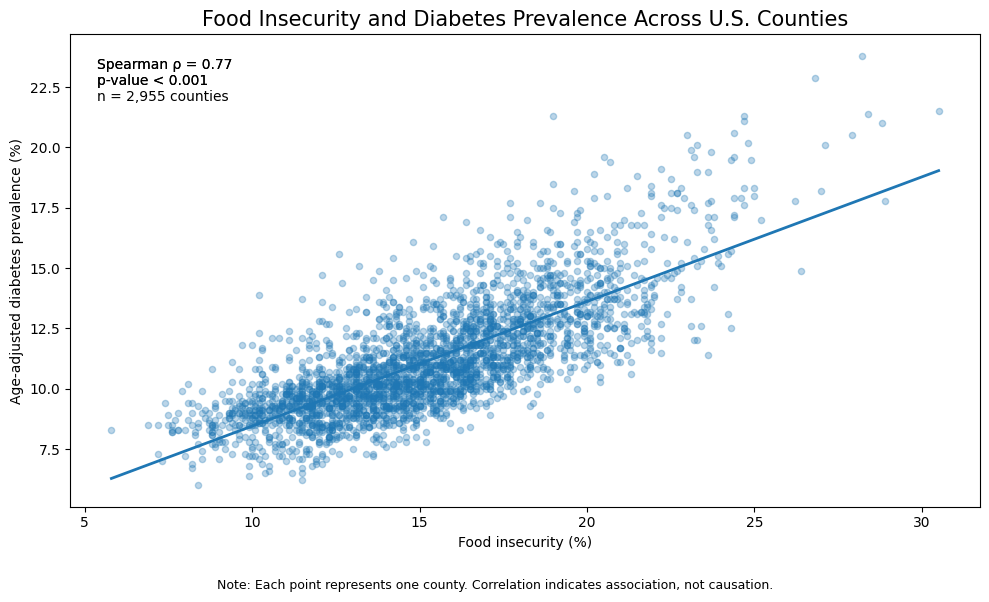

In [10]:
#EXTRA FIGURE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Keep only the two variables needed
scatter_df = df[
    ["food_insecurity_pct", "diabetes_age_adjusted_pct"]
].copy()

# Ensure both columns are numeric
scatter_df["food_insecurity_pct"] = pd.to_numeric(
    scatter_df["food_insecurity_pct"],
    errors="coerce"
)

scatter_df["diabetes_age_adjusted_pct"] = pd.to_numeric(
    scatter_df["diabetes_age_adjusted_pct"],
    errors="coerce"
)

# Examine possible invalid zeros before removing them
print("Zero food insecurity values:",
      (scatter_df["food_insecurity_pct"] == 0).sum())

print("Zero diabetes values:",
      (scatter_df["diabetes_age_adjusted_pct"] == 0).sum())

# Remove missing values and invalid zero disease estimates
scatter_df = scatter_df.dropna()

scatter_df = scatter_df[
    scatter_df["diabetes_age_adjusted_pct"] > 0
]

# Remove zero food-insecurity values if they represent missing data
scatter_df = scatter_df[
    scatter_df["food_insecurity_pct"] > 0
]

# Calculate Spearman correlation
rho, p_value = spearmanr(
    scatter_df["food_insecurity_pct"],
    scatter_df["diabetes_age_adjusted_pct"]
)

# Create a linear visual trendline
x = scatter_df["food_insecurity_pct"]
y = scatter_df["diabetes_age_adjusted_pct"]

coefficients = np.polyfit(x, y, 1)
trendline = np.poly1d(coefficients)
x_line = np.linspace(x.min(), x.max(), 100)

# Format the p-value correctly
p_text = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    x,
    y,
    alpha=0.3,
    s=20
)

ax.plot(
    x_line,
    trendline(x_line),
    linewidth=2
)

ax.set_title(
    "Food Insecurity and Diabetes Prevalence Across U.S. Counties",
    fontsize=15
)

ax.set_xlabel("Food insecurity (%)")
ax.set_ylabel("Age-adjusted diabetes prevalence (%)")

ax.text(
    0.03,
    0.95,
    f"Spearman ρ = {rho:.2f}\np-value {p_text}",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=10
)

fig.text(
    0.5,
    0.01,
    "Note: Each point represents one county. Correlation indicates association, not causation.",
    ha="center",
    fontsize=9
)

ax.text(
    0.03,
    0.95,
    f"Spearman ρ = {rho:.2f}\np-value < 0.001\nn = {n_counties:,} counties",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Text(0.03, 0.95, 'Spearman ρ = 0.77\np-value < 0.001\nn = 2,955 counties')

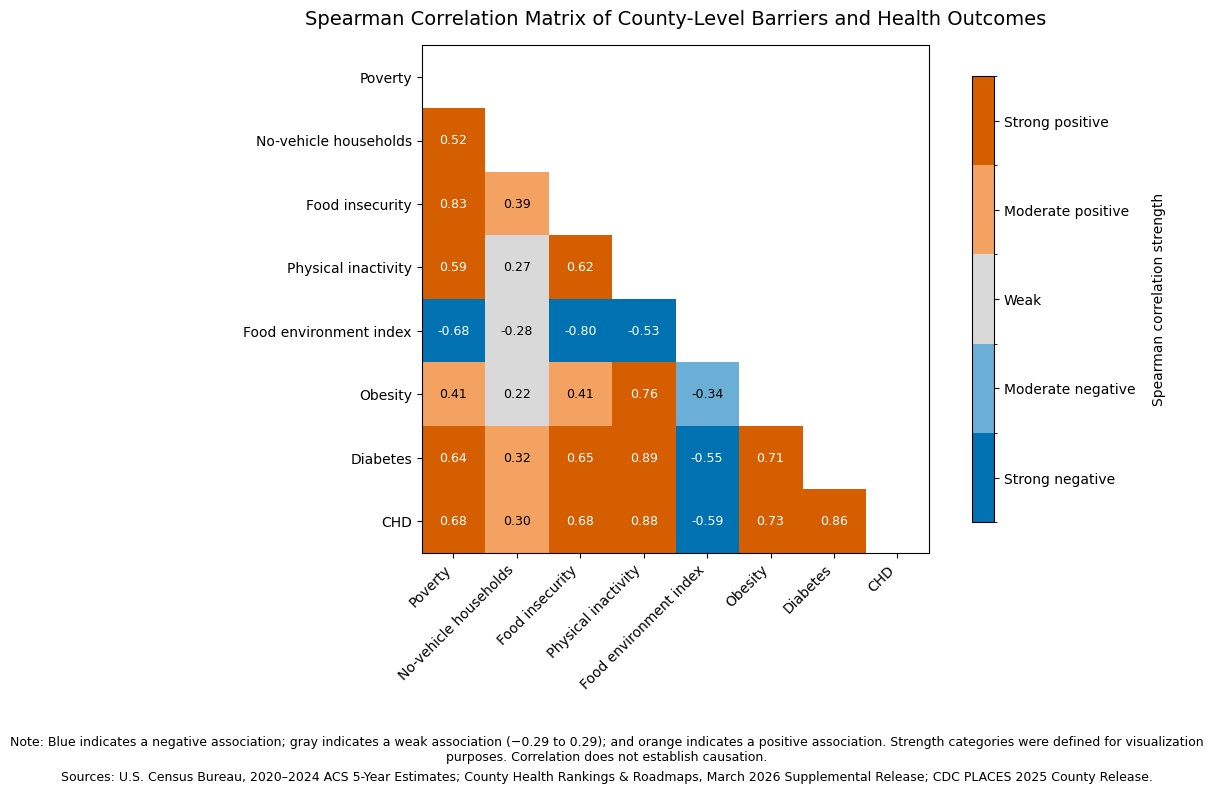

In [25]:
#EXTRA FIGURE FOR ANALYSIS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---------------------------------------------------------
# 1. Select variables and define clearer display labels
# ---------------------------------------------------------

variables = {
    "poverty_pct": "Poverty",
    "pct_no_vehicles": "No-vehicle households",
    "food_insecurity_pct": "Food insecurity",
    "physical_inactivity_pct": "Physical inactivity",
    "food_environment_index": "Food environment index",
    "obesity_age_adjusted_pct": "Obesity",
    "diabetes_age_adjusted_pct": "Diabetes",
    "chd_age_adjusted_pct": "CHD"
}

# Check whether all required columns are available
missing_columns = [
    column
    for column in variables
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

# ---------------------------------------------------------
# 2. Ensure the selected variables are numeric
# ---------------------------------------------------------

correlation_data = df[list(variables.keys())].copy()

for column in correlation_data.columns:
    correlation_data[column] = pd.to_numeric(
        correlation_data[column],
        errors="coerce"
    )

# Rename the variables for display in the figure
correlation_data = correlation_data.rename(
    columns=variables
)

# ---------------------------------------------------------
# 3. Calculate pairwise Spearman correlations
# ---------------------------------------------------------

correlation = correlation_data.corr(
    method="spearman"
)

# ---------------------------------------------------------
# 4. Hide the duplicated upper triangle and diagonal
# ---------------------------------------------------------

# k=0 hides the upper half and each variable's correlation
# with itself
mask = np.triu(
    np.ones_like(correlation, dtype=bool),
    k=0
)

masked_correlation = np.ma.array(
    correlation.to_numpy(),
    mask=mask
)

# ---------------------------------------------------------
# 5. Create discrete blue-gray-orange categories
# ---------------------------------------------------------

correlation_colors = ListedColormap([
    "#0072B2",  # strong negative
    "#6BAED6",  # moderate negative
    "#D9D9D9",  # weak
    "#F4A261",  # moderate positive
    "#D55E00"   # strong positive
])

# Keep hidden cells white
correlation_colors.set_bad("white")

# Define the correlation-strength ranges
boundaries = [
    -1.00,
    -0.50,
    -0.30,
     0.30,
     0.50,
     1.01
]

color_norm = BoundaryNorm(
    boundaries,
    correlation_colors.N,
    clip=True
)

# ---------------------------------------------------------
# 6. Create the heatmap
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 8)
)

image = ax.imshow(
    masked_correlation,
    cmap=correlation_colors,
    norm=color_norm
)

# ---------------------------------------------------------
# 7. Format axis labels
# ---------------------------------------------------------

ax.set_xticks(
    range(len(correlation.columns))
)

ax.set_yticks(
    range(len(correlation.index))
)

ax.set_xticklabels(
    correlation.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation.index
)

# ---------------------------------------------------------
# 8. Add correlation values to the visible cells
# ---------------------------------------------------------

for row in range(len(correlation.index)):
    for column in range(len(correlation.columns)):

        if not mask[row, column]:

            value = correlation.iloc[row, column]

            # White text is easier to read on darker cells
            text_color = (
                "white"
                if abs(value) >= 0.50
                else "black"
            )

            ax.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color
            )

# ---------------------------------------------------------
# 9. Add the categorical color scale
# ---------------------------------------------------------

colorbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.88,
    pad=0.04,
    boundaries=boundaries,
    ticks=[
        -0.75,
        -0.40,
         0.00,
         0.40,
         0.75
    ]
)

colorbar.ax.set_yticklabels([
    "Strong negative",
    "Moderate negative",
    "Weak",
    "Moderate positive",
    "Strong positive"
])

colorbar.set_label(
    "Spearman correlation strength",
    labelpad=12
)

# ---------------------------------------------------------
# 10. Add title, explanatory note, and sources
# ---------------------------------------------------------

ax.set_title(
    "Spearman Correlation Matrix of County-Level Barriers and Health Outcomes",
    fontsize=14,
    pad=15
)

fig.text(
    0.5,
    0.045,
    "Note: Blue indicates a negative association; gray indicates a weak "
    "association (−0.29 to 0.29); and orange indicates a positive association. "
    "Strength categories were defined for visualization purposes. "
    "Correlation does not establish causation.",
    ha="center",
    fontsize=9,
    wrap=True
)

fig.text(
    0.5,
    0.017,
    "Sources: U.S. Census Bureau, 2020–2024 ACS 5-Year Estimates; "
    "County Health Rankings & Roadmaps, March 2026 Supplemental Release; "
    "CDC PLACES 2025 County Release.",
    ha="center",
    fontsize=9,
    wrap=True
)

# Leave room for rotated labels, color bar, note, and sources
plt.tight_layout(
    rect=[0, 0.11, 1, 1]
)

# ---------------------------------------------------------
# 11. Save and display the final visualization
# ---------------------------------------------------------

plt.savefig(
    "/content/spearman_correlation_heatmap_final_2026.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
import pandas as pd

# Ensure population is numeric
check_df["total_population"] = pd.to_numeric(
    check_df["total_population"],
    errors="coerce"
)

# Keep only counties classified with compounded barriers
compounded_counties = check_df[
    check_df["barrier_profile_exact"] == "Compounded barriers"
].copy()

# Rank by total population
top5_population = (
    compounded_counties
    .dropna(subset=["total_population"])
    .sort_values("total_population", ascending=False)
    .head(5)
)

columns_to_show = [
    "county_name",
    "total_population",
    "poverty_pct",
    "pct_no_vehicles",
    "food_insecurity_pct",
    "diabetes_age_adjusted_pct"
]

# Add state if it exists as a separate column
if "state" in top5_population.columns:
    columns_to_show.insert(1, "state")

display(
    top5_population[columns_to_show]
    .reset_index(drop=True)
    .round(1)
)

,county_name,total_population,poverty_pct,pct_no_vehicles,food_insecurity_pct,diabetes_age_adjusted_pct
0,"Kings County, New York",2631580.0,19.1,56.4,17.1,11.1
1,"Wayne County, Michigan",1772259.0,20.8,11.6,17.6,12.5
2,"Philadelphia County, Pennsylvania",1579706.0,21.4,27.9,17.6,<NA>
3,"Bronx County, New York",1404779.0,27.8,61.1,22.6,14.8
4,"Shelby County, Tennessee",919173.0,17.8,8.2,15.9,14.6


In [25]:
import pandas as pd

priority_variables = [
    "food_insecurity_pct",
    "diabetes_age_adjusted_pct",
    "total_population"
]

for column in priority_variables:
    check_df[column] = pd.to_numeric(
        check_df[column],
        errors="coerce"
    )

# National county-level 75th-percentile thresholds
food_insecurity_cutoff = check_df[
    "food_insecurity_pct"
].quantile(0.75)

diabetes_cutoff = check_df[
    "diabetes_age_adjusted_pct"
].quantile(0.75)

print(
    f"Food-insecurity cutoff: {food_insecurity_cutoff:.1f}%"
)

print(
    f"Diabetes cutoff: {diabetes_cutoff:.1f}%"
)

# High-priority definition
priority_counties = check_df[
    (check_df["barrier_profile_exact"] == "Compounded barriers") &
    (check_df["food_insecurity_pct"] >= food_insecurity_cutoff) &
    (check_df["diabetes_age_adjusted_pct"] >= diabetes_cutoff)
].copy()

# Rank by population among counties meeting all priority criteria
top5_priority = (
    priority_counties
    .dropna(subset=["total_population"])
    .sort_values("total_population", ascending=False)
    .head(5)
)

columns_to_show = [
    "county_name",
    "total_population",
    "poverty_pct",
    "pct_no_vehicles",
    "food_insecurity_pct",
    "obesity_age_adjusted_pct",
    "diabetes_age_adjusted_pct",
    "chd_age_adjusted_pct"
]

if "state" in top5_priority.columns:
    columns_to_show.insert(1, "state")

display(
    top5_priority[columns_to_show]
    .reset_index(drop=True)
    .round(1)
)

Food-insecurity cutoff: 17.6%
Diabetes cutoff: 12.5%


,county_name,total_population,poverty_pct,pct_no_vehicles,food_insecurity_pct,obesity_age_adjusted_pct,diabetes_age_adjusted_pct,chd_age_adjusted_pct
0,"Wayne County, Michigan",1772259.0,20.8,11.6,17.6,37.3,12.5,6.3
1,"Bronx County, New York",1404779.0,27.8,61.1,22.6,33.7,14.8,6.3
2,"Baltimore city, Maryland",573243.0,19.7,26.7,18.4,38.8,13.7,5.9
3,"Orleans Parish, Louisiana",371853.0,22.6,17.4,18.6,34.2,14.4,6.1
4,"Merced County, California",290201.0,19.1,7.3,17.7,34.3,13.3,6.2


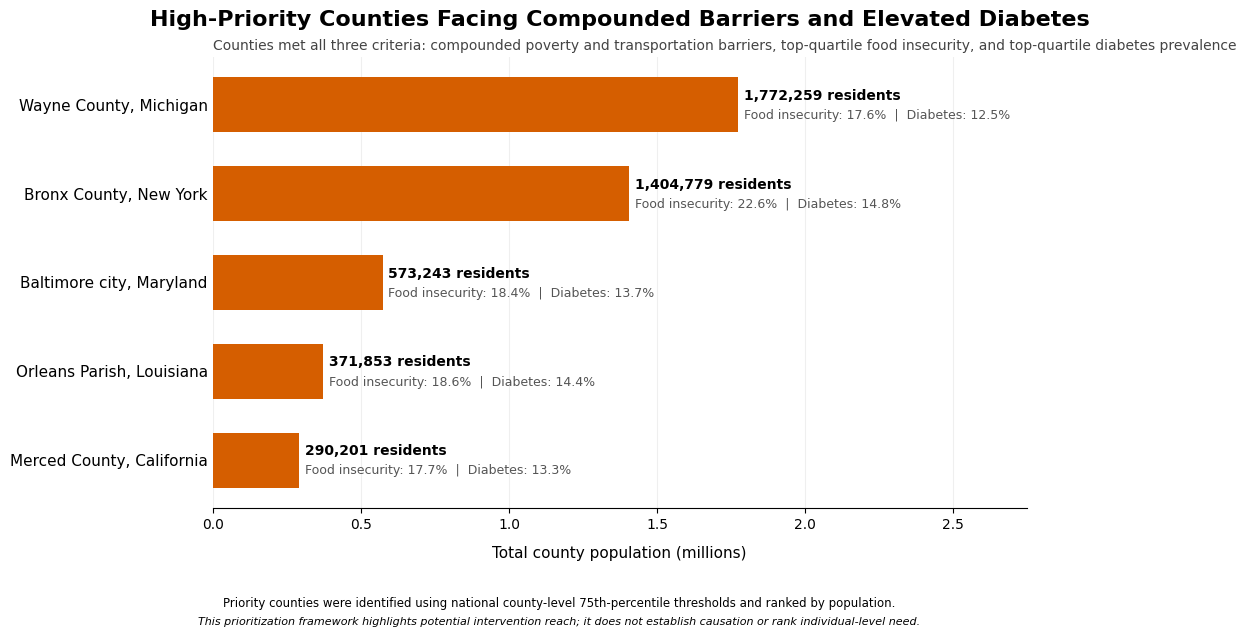

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Prepare the top-five priority counties
# --------------------------------------------------

plot_df = top5_priority.copy()

required_columns = [
    "county_name",
    "total_population",
    "food_insecurity_pct",
    "diabetes_age_adjusted_pct"
]

missing_columns = [
    column for column in required_columns
    if column not in plot_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Convert values to numeric
numeric_columns = [
    "total_population",
    "poverty_pct",
    "pct_no_vehicles",
    "food_insecurity_pct",
    "diabetes_age_adjusted_pct"
]

for column in numeric_columns:
    if column in plot_df.columns:
        plot_df[column] = pd.to_numeric(
            plot_df[column],
            errors="coerce"
        )

# Create county labels
if "state" in plot_df.columns:
    plot_df["county_label"] = (
        plot_df["county_name"].astype(str)
        + ", "
        + plot_df["state"].astype(str)
    )
else:
    plot_df["county_label"] = plot_df["county_name"].astype(str)

# Rank by population
plot_df = (
    plot_df
    .dropna(subset=["total_population"])
    .sort_values("total_population", ascending=True)
    .copy()
)

# Display population in millions
plot_df["population_millions"] = (
    plot_df["total_population"] / 1_000_000
)

# --------------------------------------------------
# Create the chart
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_df["county_label"],
    plot_df["population_millions"],
    color="#D55E00",
    height=0.62
)

# Add population and health labels
for bar, (_, row) in zip(bars, plot_df.iterrows()):

    bar_width = bar.get_width()
    bar_y = bar.get_y() + bar.get_height() / 2

    # Population label
    ax.text(
        bar_width + 0.02,
        bar_y + 0.10,
        f'{row["total_population"]:,.0f} residents',
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

    # Food insecurity and diabetes label
    ax.text(
        bar_width + 0.02,
        bar_y - 0.12,
        (
            f'Food insecurity: {row["food_insecurity_pct"]:.1f}%  |  '
            f'Diabetes: {row["diabetes_age_adjusted_pct"]:.1f}%'
        ),
        va="center",
        ha="left",
        fontsize=9,
        color="#555555"
    )

# --------------------------------------------------
# Titles and formatting
# --------------------------------------------------

ax.set_title(
    "High-Priority Counties Facing Compounded Barriers and Elevated Diabetes",
    fontsize=16,
    fontweight="bold",
    pad=22
)

ax.text(
    0,
    1.015,
    (
        "Counties met all three criteria: compounded poverty and transportation barriers, "
        "top-quartile food insecurity, and top-quartile diabetes prevalence"
    ),
    transform=ax.transAxes,
    fontsize=10,
    color="#444444"
)

ax.set_xlabel(
    "Total county population (millions)",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    labelsize=11,
    length=0
)

# Add enough space for labels to the right
maximum_population = plot_df["population_millions"].max()

ax.set_xlim(
    0,
    maximum_population * 1.55
)

# --------------------------------------------------
# Notes
# --------------------------------------------------

fig.text(
    0.5,
    0.045,
    (
        "Priority counties were identified using national county-level 75th-percentile "
        "thresholds and ranked by population."
    ),
    ha="center",
    fontsize=8.5
)

fig.text(
    0.5,
    0.020,
    (
        "This prioritization framework highlights potential intervention reach; "
        "it does not establish causation or rank individual-level need."
    ),
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout(
    rect=[0.03, 0.09, 0.98, 0.92]
)

plt.savefig(
    "/content/top5_high_priority_counties.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()